In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.model import NeuralNetwork
from src.metrics import accuracy

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
np.random.seed(42)

X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    random_state=42
)

y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
model = NeuralNetwork(
    input_dim=20,
    hidden_dim=8,
    learning_rate=0.01,
    epochs=1000
)

model.fit(X_train, y_train)

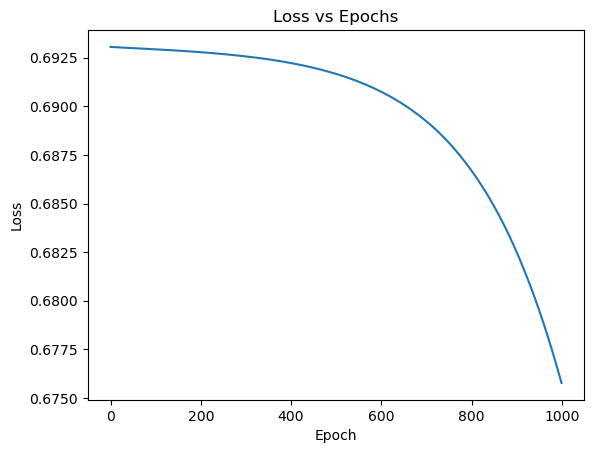

In [4]:
plt.plot(model.loss_history)
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [5]:
y_pred = model.predict(X_test)
acc = accuracy(y_test, y_pred)

print("Test Accuracy:", acc)

Test Accuracy: 0.47


In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train.ravel())

print("Sklearn Logistic:", lr.score(X_test, y_test))

Sklearn Logistic: 0.85
